In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
sns.set_palette('Greys_d')

In [4]:
df = pd.read_csv('/workspaces/Learning_Python/data/california_housing.csv')


In [5]:
print ('-----California Housing Dataset -----')
print (f'Total no. of rows: {df.shape[0]}')
print (f'Total no. of colomuns: {df.shape[1]}')
print (f'No. of duplicate records: {sum(df.duplicated())}')

-----California Housing Dataset -----
Total no. of rows: 20640
Total no. of colomuns: 10
No. of duplicate records: 0


In [6]:
round(df.isnull().sum() *100/df.shape[0],2)

longitude             0.0
latitude              0.0
housing_median_age    0.0
total_rooms           0.0
total_bedrooms        1.0
population            0.0
households            0.0
median_income         0.0
ocean_proximity       0.0
median_house_value    0.0
dtype: float64

In [7]:
df[['housing_median_age', 'total_rooms', 'total_bedrooms','population','households', 'median_income','median_house_value']].describe().describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000,8.000000
mean,2602.278131,8937.766042,3652.031953,7820.117358,3612.358679,2584.013993,177739.554098
std,7288.356721,13944.990983,7106.427031,13192.258842,7167.532601,7295.721436,156160.283798
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,16.646389,1957.187500,390.038803,1046.096591,356.747315,2.397505,91706.711906
50%,28.819743,2408.689166,486.435276,1295.738372,454.269840,3.702736,149650.000000
75%,40.750000,7521.000000,2096.500000,6453.750000,1974.250000,7.307462,221323.112682
max,20640.000000,39320.000000,20433.000000,35682.000000,20640.000000,20640.000000,500001.000000


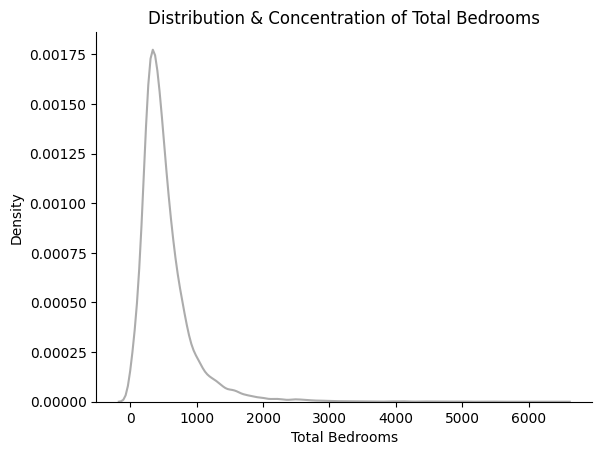

In [8]:
sns.kdeplot(data = df, x = 'total_bedrooms')
plt.title('Distribution & Concentration of Total Bedrooms')
plt.xlabel('Total Bedrooms')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

In [9]:
median_total_bedrooms = df['total_bedrooms'].median()
df['total_bedrooms']= df['total_bedrooms'].fillna(median_total_bedrooms)


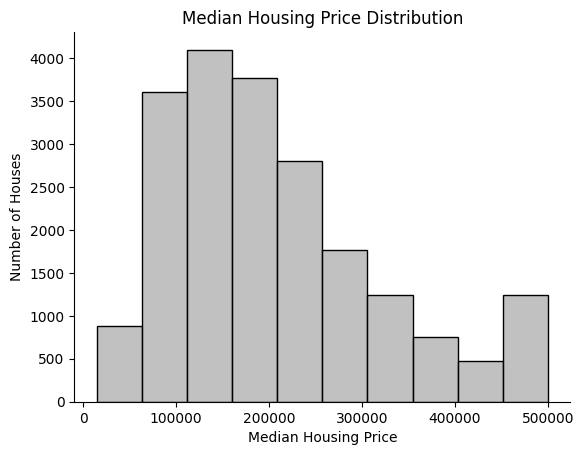

In [10]:
sns.histplot(data = df, x = 'median_house_value', binwidth= 50000)
plt.title('Median Housing Price Distribution')
plt.xlabel('Median Housing Price')
plt.ylabel("Number of Houses")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

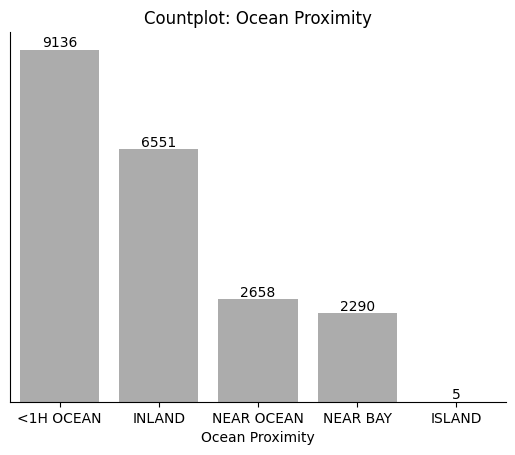

In [11]:
fig = sns.countplot(data = df, x='ocean_proximity', order = df['ocean_proximity'].value_counts().index)
for p in fig.patches:
    plt.text(p.get_x() + p.get_width()/2, p.get_height(), f'{int(p.get_height())}', ha = 'center', va = 'bottom')

plt.title('Countplot: Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('')
plt.yticks([])
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()



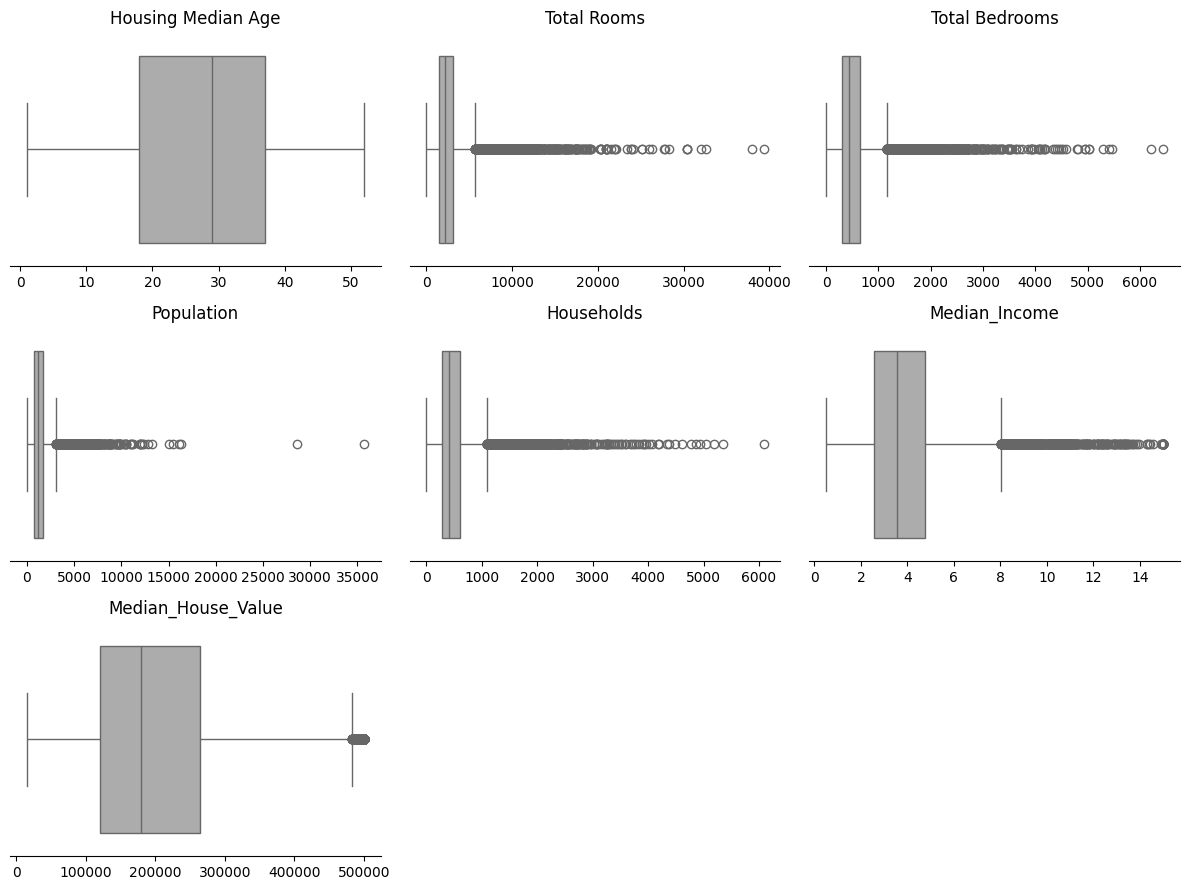

In [12]:
fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize = (12,9))

sns.boxplot(data = df, x = 'housing_median_age', ax = axs[0][0])
axs[0][0].set_title('Housing Median Age')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('')
axs[0][0].set_yticks([])
axs[0][0].spines[['top', 'right', 'left']].set_visible(False)

sns.boxplot(data = df, x = 'total_rooms', ax = axs[0][1])
axs[0][1].set_title('Total Rooms')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('')
axs[0][1].set_yticks([])
axs[0][1].spines[['top', 'right', 'left']].set_visible(False)

sns.boxplot(data = df, x = 'total_bedrooms', ax = axs[0][2])
axs[0][2].set_title('Total Bedrooms')
axs[0][2].set_xlabel('')
axs[0][2].set_ylabel('')
axs[0][2].set_yticks([])
axs[0][2].spines[['top', 'right', 'left']].set_visible(False)

sns.boxplot(data = df, x = 'population', ax = axs[1][0])
axs[1][0].set_title('Population')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('')
axs[1][0].set_yticks([])
axs[1][0].spines[['top', 'right', 'left']].set_visible(False)

sns.boxplot(data = df, x = 'households', ax = axs[1][1])
axs[1][1].set_title('Households')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('')
axs[1][1].set_yticks([])
axs[1][1].spines[['top', 'right', 'left']].set_visible(False)


sns.boxplot(data = df, x = 'median_income', ax = axs[1][2])
axs[1][2].set_title('Median_Income')
axs[1][2].set_xlabel('')
axs[1][2].set_ylabel('')
axs[1][2].set_yticks([])
axs[1][2].spines[['top', 'right', 'left']].set_visible(False)

sns.boxplot(data = df, x = 'median_house_value', ax = axs[2][0])
axs[2][0].set_title('Median_House_Value')
axs[2][0].set_xlabel('')
axs[2][0].set_ylabel('')
axs[2][0].set_yticks([])
axs[2][0].spines[['top', 'right', 'left']].set_visible(False)

axs[2][1].set_visible(False)
axs[2][2].set_visible(False)

plt.tight_layout()

plt.show()

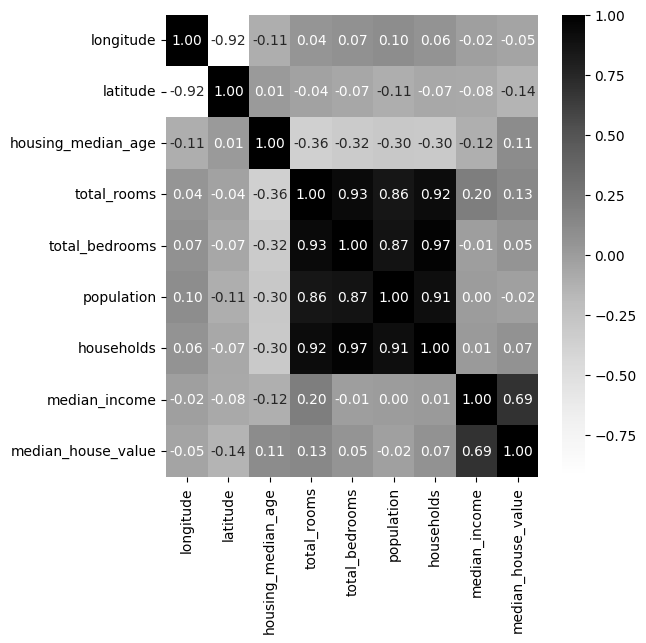

In [14]:
#correlation plot
plt.figure(figsize=(6, 6))
sns.heatmap(df.drop('ocean_proximity', axis=1).corr(),annot=True, fmt='.2f', cmap='Greys')
plt.show()

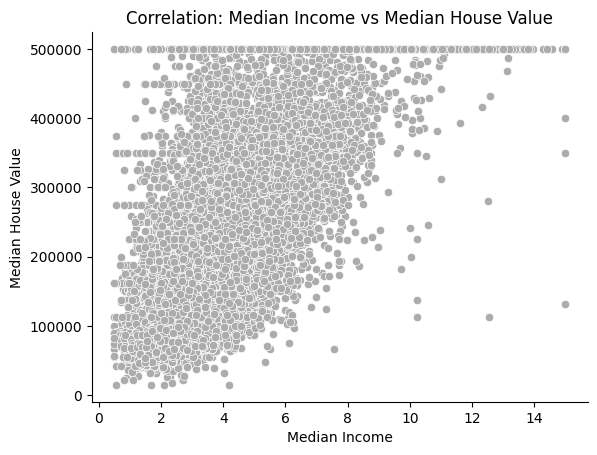

In [15]:
#correlation between median_income and median_house_value using scatter plot
sns.scatterplot(data = df, x='median_income', y = 'median_house_value')
plt.title('Correlation: Median Income vs Median House Value')
plt.xlabel('Median Income')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

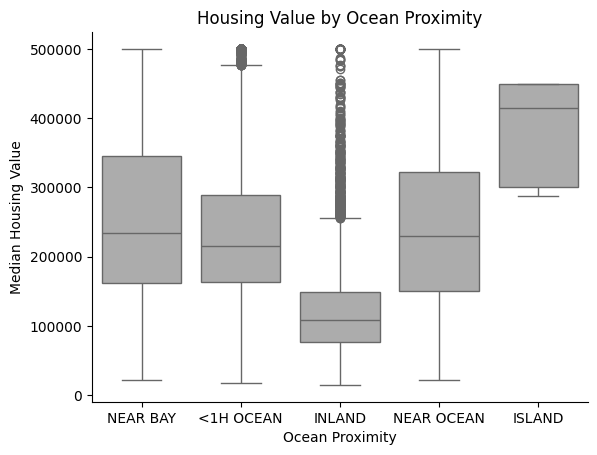

In [16]:
#how does proximit to the ocean incluences housing price
sns.boxplot(data = df, x = 'ocean_proximity', y = 'median_house_value')
plt.title('Housing Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median Housing Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

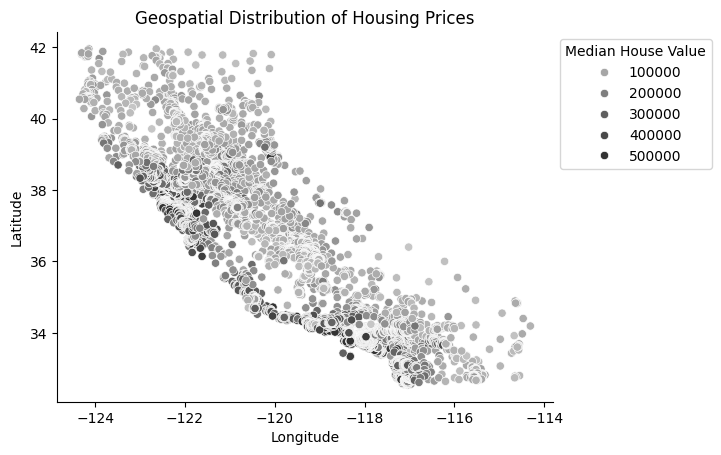

In [17]:
#how price affected by geography
sns.scatterplot(data = df, x = 'longitude', y = 'latitude', hue = 'median_house_value', palette= 'Greys_d')
plt.title('Geospatial Distribution of Housing Prices')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.legend(title = 'Median House Value', bbox_to_anchor = (1,1), loc = 'upper left')
plt.show()

In [18]:
#feature engineering
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_houshold'] = df['population'] / df['households']
df['income_per_household'] = df['median_income'] / df['households']
df['bedrooms_per_person'] = df['total_bedrooms'] / df['population']
df['rooms_per_person'] = df['total_rooms'] / df['population']
df['region'] = pd.cut(df['latitude'], bins = [32,34,36,38,40,42], labels = ['South', 'Lower Central', 'Central', 'North Central', 'North'])
df['population_per_household_bins'] = pd.cut(df['population_per_houshold'], bins = [0, 2, 4, 6, np.inf], labels = ['<2','2-4','4-6', '6+'])
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value,rooms_per_household,bedrooms_per_room,population_per_houshold,income_per_household,bedrooms_per_person,rooms_per_person,region,population_per_household_bins
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600,6.984127,0.146591,2.555556,0.066073,0.400621,2.732919,Central,2-4
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500,6.238137,0.155797,2.109842,0.007295,0.460641,2.956685,Central,2-4
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100,8.288136,0.129516,2.802260,0.041002,0.383065,2.957661,Central,2-4
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300,5.817352,0.184458,2.547945,0.025768,0.421147,2.283154,Central,2-4
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200,6.281853,0.172096,2.181467,0.014850,0.495575,2.879646,Central,2-4


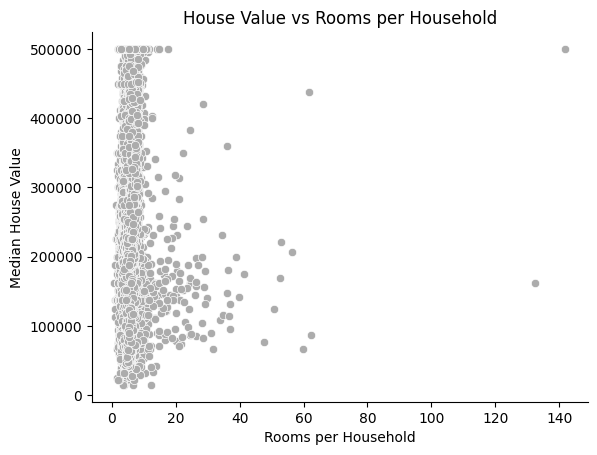

In [19]:
#relation between average number of rooms per household and house value
sns.scatterplot(data = df, x = 'rooms_per_household', y = 'median_house_value')
plt.title('House Value vs Rooms per Household')
plt.xlabel('Rooms per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

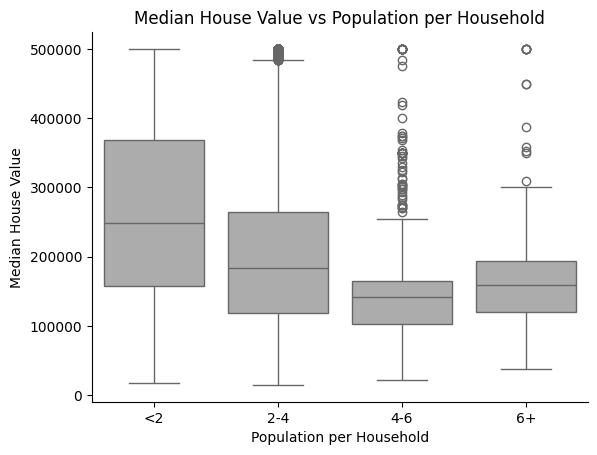

In [20]:
#average number of people per household vs median house value
sns.boxplot(data = df, x = 'population_per_household_bins', y = 'median_house_value')
plt.title('Median House Value vs Population per Household')
plt.xlabel('Population per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

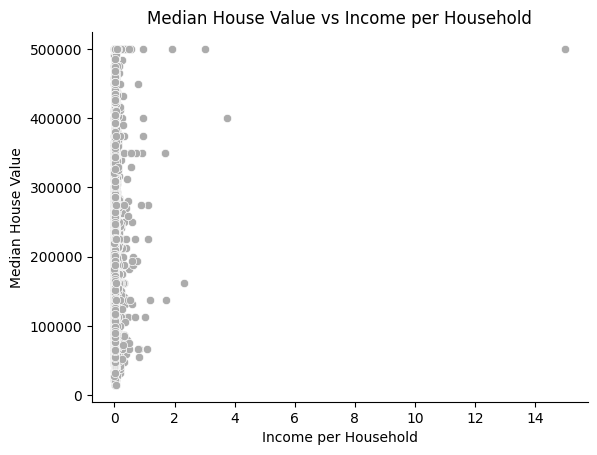

In [21]:
#income per household vs median house value
sns.scatterplot(data = df, x = 'income_per_household', y = 'median_house_value')
plt.title('Median House Value vs Income per Household')
plt.xlabel('Income per Household')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

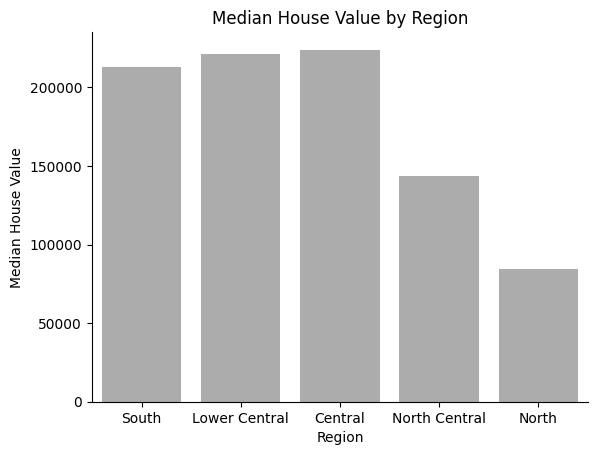

In [22]:
#median house value across regions
sns.barplot(data = df, x = 'region', y = 'median_house_value', errorbar= ('ci',False))
plt.title('Median House Value by Region')
plt.xlabel('Region')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()